In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import pearsonr
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.metrics import r2_score


In [2]:
# def plot_precipitation_comparison_uy(
#     basin: str,
#     extended_dataset_dir: Path,
#     start_date: str = "1989-10-01",
#     end_date: str = "2008-09-30",
#     vmax_heatmap: float = 7.0,
#     save_path: Path = None,
# ):
#     """
#     Plot precipitation comparison for a single basin across four products:
#     CARAVAN, gauge, CHIRPS, and MSWEP.

#     Parameters
#     ----------
#     basin : str
#         Basin ID, e.g. "CAMELS_UY_*"
#     extended_dataset_dir : Path
#         Directory containing extended NetCDF files (with CHIRPS/MSWEP).
#     start_date : str
#         Start of analysis period (inclusive), default "1989-10-01".
#     end_date : str
#         End of analysis period (inclusive), default "2008-09-30".
#     vmax_heatmap : float
#         Max value for the seasonal heatmap colorbar, default 7.
#     save_path : Path, optional
#         If provided, saves the figure to this path instead of showing it.
#     """

#     # ------------------------------------------------------------------ #
#     # Load data
#     # ------------------------------------------------------------------ #
#     data_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")

#     # ------------------------------------------------------------------ #
#     # Build xarray DataArrays
#     # ------------------------------------------------------------------ #
#     precip_caravan = data_nc["prcp_mm_day"]
#     precip_chirps  = data_nc["prcp_chirps_mm_day"]
#     precip_mswep   = data_nc["prcp_mswep_mm_day"]
#     precip_gauge = data_nc["prcp_gauge_mm_day"]

#     # ------------------------------------------------------------------ #
#     # Align and slice
#     # ------------------------------------------------------------------ #
#     precip_caravan, precip_gauge, precip_chirps, precip_mswep = xr.align(
#         precip_caravan, precip_gauge, precip_chirps, precip_mswep, join="inner"
#     )

#     t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
#     sl = slice(t0, t1)

#     caravan = precip_caravan.sel(date=sl)
#     gauge  = precip_gauge.sel(date=sl)
#     chirps  = precip_chirps.sel(date=sl)
#     mswep   = precip_mswep.sel(date=sl)

#     # ------------------------------------------------------------------ #
#     # Cumulative sums
#     # ------------------------------------------------------------------ #
#     cum_caravan = caravan.cumsum(dim="date").values.flatten()
#     cum_gauge  = gauge.cumsum(dim="date").values.flatten()
#     cum_chirps  = chirps.cumsum(dim="date").values.flatten()
#     cum_mswep   = mswep.cumsum(dim="date").values.flatten()

#     # ------------------------------------------------------------------ #
#     # Flow duration curve helpers
#     # ------------------------------------------------------------------ #
#     def _fdc(da):
#         arr = da.values.flatten()
#         arr = arr[~np.isnan(arr)]
#         arr_sorted = np.sort(arr)[::-1]
#         ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
#         arr_plot = np.where(arr_sorted == 0, 1e-9, arr_sorted)
#         return ep, arr_plot

#     ep_caravan, pr_caravan_plot = _fdc(caravan)
#     ep_gauge,  pr_gauge_plot  = _fdc(gauge)
#     ep_chirps,  pr_chirps_plot  = _fdc(chirps)
#     ep_mswep,   pr_mswep_plot   = _fdc(mswep)

#     # ------------------------------------------------------------------ #
#     # Dry spell lengths
#     # ------------------------------------------------------------------ #
#     def _dry_lengths(da):
#         mask = (da.values.flatten() == 0)
#         diff = np.diff(mask.astype(int))
#         starts = np.where(diff == 1)[0] + 1
#         ends   = np.where(diff == -1)[0] + 1
#         if mask[0]:  starts = np.r_[0, starts]
#         if mask[-1]: ends   = np.r_[ends, len(mask)]
#         return ends - starts

#     dry_caravan = _dry_lengths(caravan)
#     dry_gauge  = _dry_lengths(gauge)
#     dry_chirps  = _dry_lengths(chirps)
#     dry_mswep   = _dry_lengths(mswep)

#     bins = np.arange(1, max(dry_caravan.max(), dry_gauge.max(),
#                             dry_chirps.max(), dry_mswep.max()) + 2) - 0.5

#     # ------------------------------------------------------------------ #
#     # Seasonal cycle (median by DOY)
#     # ------------------------------------------------------------------ #
#     dates = pd.to_datetime(caravan.date.values)
#     df_doy = pd.DataFrame({
#         "doy":     dates.dayofyear,
#         "caravan": caravan.values,
#         "gauge":  gauge.values,
#         "chirps":  chirps.values,
#         "mswep":   mswep.values,
#     })

#     def _median_doy(col):
#         med = df_doy.groupby("doy")[col].median().values
#         return med[:365] if len(med) == 366 else med

#     all_precip = np.array([
#         _median_doy("caravan"),
#         _median_doy("gauge"),
#         _median_doy("chirps"),
#         _median_doy("mswep"),
#     ])

#     # ------------------------------------------------------------------ #
#     # Plot
#     # ------------------------------------------------------------------ #
#     fig, ax = plt.subplots(2, 2, figsize=(10, 8))
#     fig.suptitle(f"Basin: {basin}", fontsize=13, fontweight="bold")

#     # A) Cumulative
#     max_val = max(cum_caravan.max(), cum_gauge.max(),
#                   cum_chirps.max(), cum_mswep.max())
#     ax[0, 0].plot(cum_caravan, cum_gauge, label="GAUGE")
#     ax[0, 0].plot(cum_caravan, cum_chirps, label="CHIRPS")
#     ax[0, 0].plot(cum_caravan, cum_mswep,  label="MSWEP")
#     ax[0, 0].plot([0, max_val], [0, max_val], "r--", label="1:1 line")
#     ax[0, 0].set(xlabel="Cumulative CARAVAN (mm)",
#                  ylabel="Cumulative Precipitation (mm)",
#                  title="A) Cumulative Precipitation Comparison")
#     ax[0, 0].legend()
#     ax[0, 0].grid(True)

#     # B) Flow duration curve
#     for ep, pr, lbl in [
#         (ep_caravan, pr_caravan_plot, "CARAVAN"),
#         (ep_gauge,  pr_gauge_plot,  "GAUGE"),
#         (ep_chirps,  pr_chirps_plot,  "CHIRPS"),
#         (ep_mswep,   pr_mswep_plot,   "MSWEP"),
#     ]:
#         ax[0, 1].plot(ep, pr, lw=2, label=lbl)
#     ax[0, 1].set(xlabel="Exceedance probability (%)",
#                  ylabel="Daily precipitation (mm)",
#                  title="B) Precipitation Duration Curve",
#                  yscale="log")
#     ax[0, 1].legend()
#     ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)
#     ax[0, 1].set_ylim(bottom=1e-2)

#     # C) Dry spell histogram
#     for lengths, lbl in [
#         (dry_caravan, "CARAVAN"),
#         (dry_gauge,  "GAUGE"),
#         (dry_chirps,  "CHIRPS"),
#         (dry_mswep,   "MSWEP"),
#     ]:
#         ax[1, 0].hist(lengths, bins=bins, histtype="step", lw=2, label=lbl)
#     ax[1, 0].set(xlabel="Dry spell length (days)",
#                  ylabel="Frequency",
#                  title="C) Histogram of Dry Period Lengths")
#     ax[1, 0].legend()
#     ax[1, 0].grid(True, ls="--", alpha=0.5)

#     # D) Seasonal heatmap
#     im = ax[1, 1].imshow(all_precip, aspect="auto", cmap="viridis",
#                          vmin=0, vmax=vmax_heatmap, interpolation="nearest")
#     ax[1, 1].set_yticks([0, 1, 2, 3])
#     ax[1, 1].set_yticklabels(["CARAVAN", "GAUGE", "CHIRPS", "MSWEP"])
#     ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
#                  title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
#     plt.colorbar(im, ax=ax[1, 1]).set_label("Median Precip (mm)")

#     plt.tight_layout()
#     plt.subplots_adjust(hspace=0.35, wspace=0.3)

#     if save_path:
#         fig.savefig(save_path, dpi=150, bbox_inches="tight")
#         plt.close(fig)
#         print(f"Saved: {save_path}")
#     else:
#         plt.show()

In [3]:
def plot_precipitation_comparison_uy(
    basin: str,
    extended_dataset_dir: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2008-09-30",
    vmax_heatmap: float = 7.0,
    save_path: Path = None,
):
    # ------------------------------------------------------------------ #
    # Load data
    # ------------------------------------------------------------------ #
    data_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")

    precip_caravan = data_nc["prcp_mm_day"]
    precip_chirps  = data_nc["prcp_chirps_mm_day"]
    precip_mswep   = data_nc["prcp_mswep_mm_day"]
    precip_gauge   = data_nc["prcp_gauge_mm_day"]

    precip_caravan, precip_gauge, precip_chirps, precip_mswep = xr.align(
        precip_caravan, precip_gauge, precip_chirps, precip_mswep, join="inner"
    )

    t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
    sl = slice(t0, t1)

    caravan = precip_caravan.sel(date=sl)
    gauge   = precip_gauge.sel(date=sl)
    chirps  = precip_chirps.sel(date=sl)
    mswep   = precip_mswep.sel(date=sl)

    # ------------------------------------------------------------------ #
    # Cumulative sums
    # ------------------------------------------------------------------ #
    cum_caravan = caravan.cumsum(dim="date").values.flatten()
    cum_gauge   = gauge.cumsum(dim="date").values.flatten()
    cum_chirps  = chirps.cumsum(dim="date").values.flatten()
    cum_mswep   = mswep.cumsum(dim="date").values.flatten()

    # ------------------------------------------------------------------ #
    # Flow duration curve
    # ------------------------------------------------------------------ #
    def _fdc(da):
        arr = da.values.flatten()
        arr = arr[~np.isnan(arr)]
        arr_sorted = np.sort(arr)[::-1]
        ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
        arr_plot = np.where(arr_sorted == 0, 1e-9, arr_sorted)
        return ep, arr_plot

    ep_caravan, pr_caravan_plot = _fdc(caravan)
    ep_gauge,   pr_gauge_plot   = _fdc(gauge)
    ep_chirps,  pr_chirps_plot  = _fdc(chirps)
    ep_mswep,   pr_mswep_plot   = _fdc(mswep)

    # ------------------------------------------------------------------ #
    # Dry period lengths
    # ------------------------------------------------------------------ #
    def _dry_lengths(da):
        mask   = (da.values.flatten() == 0)
        diff   = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1
        if mask[0]:  starts = np.r_[0, starts]
        if mask[-1]: ends   = np.r_[ends, len(mask)]
        return ends - starts

    dry_caravan = _dry_lengths(caravan)
    dry_gauge   = _dry_lengths(gauge)
    dry_chirps  = _dry_lengths(chirps)
    dry_mswep   = _dry_lengths(mswep)

    bins = np.arange(1, max(dry_caravan.max(), dry_gauge.max(),
                            dry_chirps.max(), dry_mswep.max()) + 2) - 0.5

    # ------------------------------------------------------------------ #
    # Seasonal cycle (median and mean by DOY)
    # ------------------------------------------------------------------ #
    dates  = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":     dates.dayofyear,
        "caravan": caravan.values,
        "gauge":   gauge.values,
        "chirps":  chirps.values,
        "mswep":   mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    def _mean_doy(col):
        mn = df_doy.groupby("doy")[col].mean().values
        return mn[:365] if len(mn) == 366 else mn

    all_precip_median = np.array([
        _median_doy("caravan"),
        _median_doy("gauge"),
        _median_doy("chirps"),
        _median_doy("mswep"),
    ])

    all_precip_mean = np.array([
        _mean_doy("caravan"),
        _mean_doy("gauge"),
        _mean_doy("chirps"),
        _mean_doy("mswep"),
    ])

    # ------------------------------------------------------------------ #
    # Plot (2×3 grid, last slot hidden)
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Basin: {basin}", fontsize=13, fontweight="bold")

    ax = axes

    # A) Cumulative
    max_val = max(cum_caravan.max(), cum_gauge.max(),
                  cum_chirps.max(), cum_mswep.max())
    ax[0, 0].plot(cum_caravan, cum_gauge,  label="GAUGE")
    ax[0, 0].plot(cum_caravan, cum_chirps, label="CHIRPS")
    ax[0, 0].plot(cum_caravan, cum_mswep,  label="MSWEP")
    ax[0, 0].plot([0, max_val], [0, max_val], "r--", label="1:1 line")
    ax[0, 0].set(xlabel="Cumulative CARAVAN (mm)",
                 ylabel="Cumulative Precipitation (mm)",
                 title="A) Cumulative Precipitation Comparison")
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # B) Flow duration curve
    for ep, pr, lbl in [
        (ep_caravan, pr_caravan_plot, "CARAVAN"),
        (ep_gauge,   pr_gauge_plot,   "GAUGE"),
        (ep_chirps,  pr_chirps_plot,  "CHIRPS"),
        (ep_mswep,   pr_mswep_plot,   "MSWEP"),
    ]:
        ax[0, 1].plot(ep, pr, lw=2, label=lbl)
    ax[0, 1].set(xlabel="Exceedance probability (%)",
                 ylabel="Daily precipitation (mm)",
                 title="B) Precipitation Duration Curve",
                 yscale="log")
    ax[0, 1].legend()
    ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)
    ax[0, 1].set_ylim(bottom=1e-2)

    # C) Dry period histogram
    for lengths, lbl in [
        (dry_caravan, "CARAVAN"),
        (dry_gauge,   "GAUGE"),
        (dry_chirps,  "CHIRPS"),
        (dry_mswep,   "MSWEP"),
    ]:
        ax[0, 2].hist(lengths, bins=bins, histtype="step", lw=2, label=lbl)
    ax[0, 2].set(xlabel="Dry period length (days)",
                 ylabel="Frequency",
                 title="C) Histogram of Dry Period Lengths")
    ax[0, 2].legend()
    ax[0, 2].grid(True, ls="--", alpha=0.5)

    # D) Seasonal heatmap — median
    im1 = ax[1, 0].imshow(all_precip_median, aspect="auto", cmap="viridis",
                          vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 0].set_yticks([0, 1, 2, 3])
    ax[1, 0].set_yticklabels(["CARAVAN", "GAUGE", "CHIRPS", "MSWEP"])
    ax[1, 0].set(xlabel="Day of Year", ylabel="Product",
                 title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im1, ax=ax[1, 0]).set_label("Median Precip (mm)")

    # E) Seasonal heatmap — mean
    im2 = ax[1, 1].imshow(all_precip_mean, aspect="auto", cmap="viridis",
                          vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 1].set_yticks([0, 1, 2, 3])
    ax[1, 1].set_yticklabels(["CARAVAN", "GAUGE", "CHIRPS", "MSWEP"])
    ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
                 title=f"E) Mean Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im2, ax=ax[1, 1]).set_label("Mean Precip (mm)")

    # hide last slot
    ax[1, 2].set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

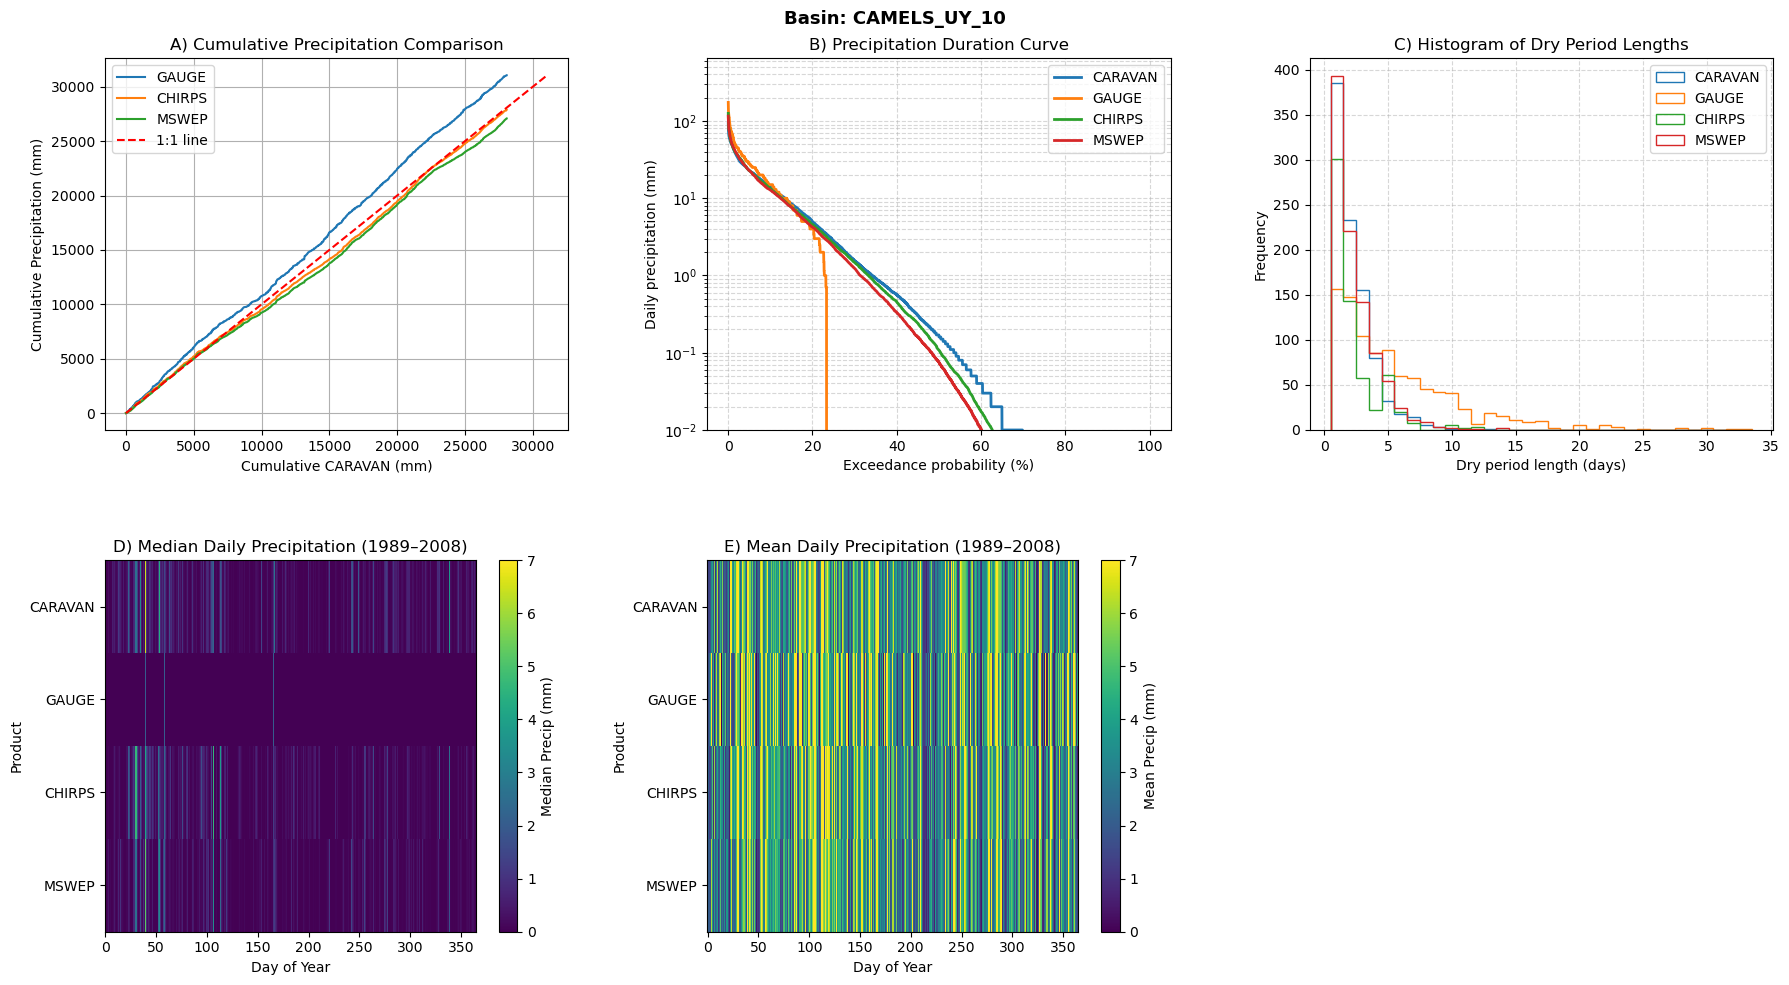

In [4]:
plot_precipitation_comparison_uy(
        basin="CAMELS_UY_10",
        extended_dataset_dir=Path("../data/time_series"),
        # data_caravan=data_caravan,
        # data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

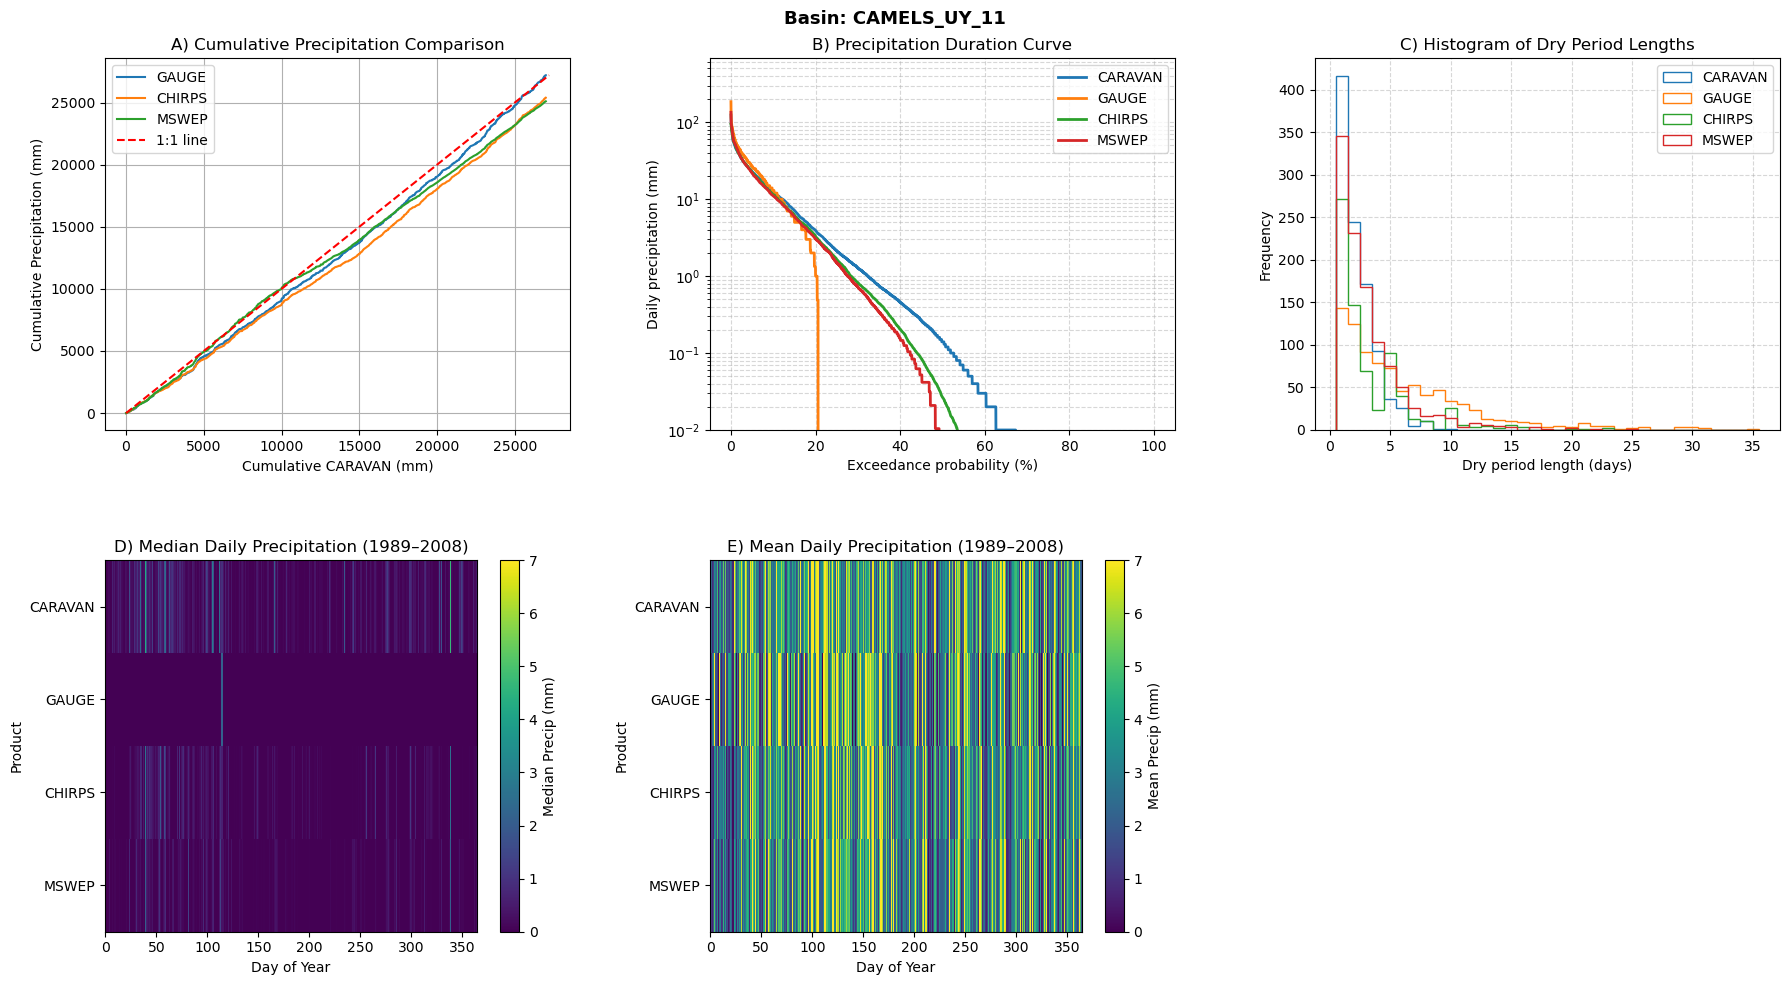

In [5]:
plot_precipitation_comparison_uy(
        basin="CAMELS_UY_11",
        extended_dataset_dir=Path("../data/time_series"),
        # data_caravan=data_caravan,
        # data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

In [6]:
extended_dataset_dir=Path("../data/time_series")

In [7]:
basin = xr.open_dataset(extended_dataset_dir / "CAMELS_UY_10.nc")
basin

<xarray.Dataset> Size: 498kB
Dimensions:             (date: 11322)
Coordinates:
  * date                (date) datetime64[ns] 91kB 1989-01-01 ... 2019-12-31
Data variables:
    tmin_C              (date) float32 45kB ...
    tmax_C              (date) float32 45kB ...
    srad_W_m2           (date) float32 45kB ...
    prcp_mm_day         (date) float32 45kB ...
    QObs_mm_d           (date) float64 91kB ...
    prcp_gauge_mm_day   (date) float32 45kB ...
    prcp_mswep_mm_day   (date) float32 45kB ...
    prcp_chirps_mm_day  (date) float32 45kB ...
Attributes:
    precip_update:  Gauge, MSWEP and CHIRPS added where available

In [8]:

# # ── Configuration ──────────────────────────────────────────────────────────────
# extended_dataset_dir = Path("../data/time_series")
# START_DATE = "1989-10-01"
# END_DATE   = "2008-09-30"

# PRODUCTS = ["GAUGE", "CHIRPS", "MSWEP"]
# VAR_MAP  = {
#     "CARAVAN": "prcp_mm_day",
#     "GAUGE":   "prcp_gauge_mm_day",
#     "CHIRPS":  "prcp_chirps_mm_day",
#     "MSWEP":   "prcp_mswep_mm_day",
# }

# PALETTE = {
#     "GAUGE":  "#3A86FF",   # blue
#     "CHIRPS": "#FF6B6B",   # coral
#     "MSWEP":  "#2EC4B6",   # teal
# }

# def volume_ratio(arr, ref):
#     s = np.nansum(ref)
#     return np.nansum(arr) / s if s > 0 else np.nan

# def p95_ratio(arr, ref):
#     p = np.nanpercentile(ref, 95)
#     return np.nanpercentile(arr, 95) / p if p > 0 else np.nan

# def mean_dry_spell(arr):
#     arr_clean = arr[~np.isnan(arr)]
#     mask   = arr_clean == 0
#     diff   = np.diff(mask.astype(int))
#     starts = np.where(diff ==  1)[0] + 1
#     ends   = np.where(diff == -1)[0] + 1
#     if mask[0]:  starts = np.r_[0, starts]
#     if mask[-1]: ends   = np.r_[ends, len(mask)]
#     lengths = (ends - starts)
#     lengths = lengths[lengths > 0]
#     return np.mean(lengths) if len(lengths) > 0 else np.nan

# def dry_spell_ratio(arr, ref):
#     m_ref = mean_dry_spell(ref)
#     m_arr = mean_dry_spell(arr)
#     return m_arr / m_ref if (m_ref and not np.isnan(m_ref) and m_ref > 0) else np.nan

# def seasonal_median(arr, dates):
#     df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
#     med = df.groupby("doy")["val"].median()
#     full = pd.Series(0.0, index=np.arange(1, 366))
#     full.update(med)
#     return full.values

# def seasonal_corr(arr, ref, dates):
#     s_ref = seasonal_median(ref, dates)
#     s_arr = seasonal_median(arr, dates)
#     if np.std(s_ref) == 0 or np.std(s_arr) == 0:
#         return np.nan
#     r, _ = pearsonr(s_ref, s_arr)
#     return r

# # ── Load basins → build tidy DataFrame ────────────────────────────────────────
# records = []

# for nc_path in sorted(extended_dataset_dir.glob("*.nc")):
#     try:
#         ds    = xr.open_dataset(nc_path).sel(
#                     date=slice(START_DATE, END_DATE))
#         dates = pd.to_datetime(ds["date"].values)
#         ref   = ds[VAR_MAP["CARAVAN"]].values.flatten().astype(float)
#         if np.nansum(ref) == 0:
#             continue

#         for prod in PRODUCTS:
#             if VAR_MAP[prod] not in ds:
#                 continue
#             arr = ds[VAR_MAP[prod]].values.flatten().astype(float)
#             records.append({
#                 "basin":   nc_path.stem,
#                 "product": prod,
#                 "vol":     volume_ratio(arr, ref),
#                 "p95":     p95_ratio(arr, ref),
#                 "dry":     dry_spell_ratio(arr, ref),
#                 "seas":    seasonal_corr(arr, ref, dates),
#             })
#     except Exception as e:
#         print(f"Skipping {nc_path.name}: {e}")

# df = pd.DataFrame(records)

# # ── Plot ───────────────────────────────────────────────────────────────────────
# PANEL_CFG = [
#     ("vol",  "A) Total Volume Bias",        "sum(product) / sum(CARAVAN)"),
#     ("p95",  "B) P95 Precipitation Bias",   "P95(product) / P95(CARAVAN)"),
#     ("dry",  "C) Mean Dry Spell Bias",       "mean dry spell ratio"),
#     ("seas", "D) Seasonal Correlation",      "Pearson r vs CARAVAN"),
# ]

# fig, axes = plt.subplots(2, 2, figsize=(13, 10))
# fig.suptitle(f"Inter-Product Agreement vs CARAVAN  (N={df['basin'].nunique()} basins)",
#              fontsize=14, fontweight="bold")

# for ax, (col, title, ylabel) in zip(axes.flat, PANEL_CFG):
#     sns.violinplot(
#         data=df, x="product", y=col,
#         hue="product", legend=False,   # ← add these two
#         palette=PALETTE, order=PRODUCTS,
#         inner="box",
#         ax=ax,
#         # linewidth=0,
#         inner_kws={"box_width": 12, "whis_width": 2},  # ← controls width 
#         alpha=0.35, 
#         saturation=0.9
#     )
#     # sns.stripplot(
#     #     data=df, x="product", y=col,
#     #     hue="product", legend=False,   # ← add these two
#     #     palette=PALETTE, order=PRODUCTS,
#     #     size=4, alpha=0.6, jitter=True,
#     #     ax=ax,
#     # )
#     ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
#     ax.set_title(title, fontweight="bold")
#     ax.set_ylabel(ylabel)
#     ax.set_xlabel("")

# legend_handles = [Patch(color=PALETTE[p], label=p, alpha=0.35) for p in PRODUCTS]
# fig.legend(handles=legend_handles, loc="lower center", ncol=3,
#            fontsize=10, bbox_to_anchor=(0.5, 0.0))

# plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.show()

Processed 11 basins.


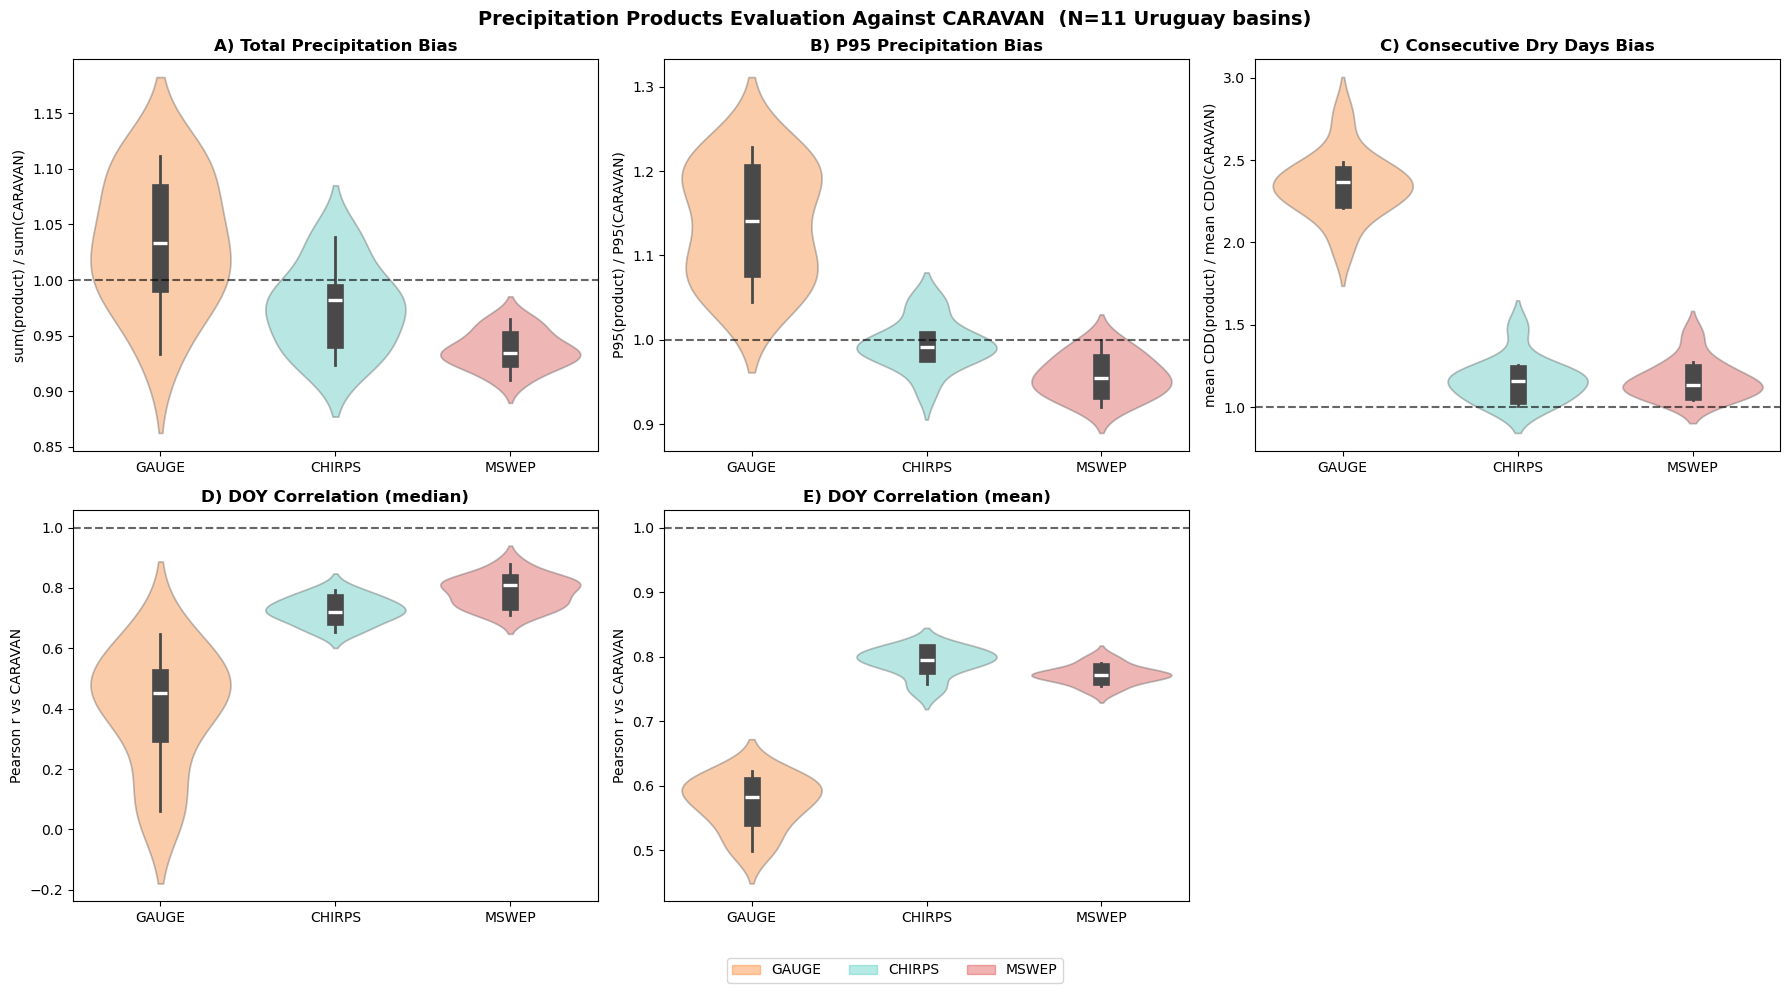

In [9]:
# ── Configuration ──────────────────────────────────────────────────────────────
extended_dataset_dir = Path("../data/time_series")
START_DATE = "1989-10-01"
END_DATE   = "2008-09-30"
PRODUCTS = ["GAUGE", "CHIRPS", "MSWEP"]
VAR_MAP  = {
    "CARAVAN": "prcp_mm_day",
    "GAUGE":   "prcp_gauge_mm_day",
    "CHIRPS":  "prcp_chirps_mm_day",
    "MSWEP":   "prcp_mswep_mm_day",
}
PALETTE = {
    "GAUGE": "#FF6B00", #"#3A86FF",
    "CHIRPS": "#2EC4B6",
    "MSWEP":  "#DC2626",
}

# ── Metric helpers ─────────────────────────────────────────────────────────────
def volume_ratio(arr, ref):
    s = np.nansum(ref)
    return np.nansum(arr) / s if s > 0 else np.nan

def p95_ratio(arr, ref):
    p = np.nanpercentile(ref, 95)
    return np.nanpercentile(arr, 95) / p if p > 0 else np.nan

def mean_dry_spell(arr):
    arr_clean = arr[~np.isnan(arr)]
    mask   = arr_clean == 0
    diff   = np.diff(mask.astype(int))
    starts = np.where(diff ==  1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, len(mask)]
    lengths = (ends - starts)
    lengths = lengths[lengths > 0]
    return np.mean(lengths) if len(lengths) > 0 else np.nan

def dry_spell_ratio(arr, ref):
    m_ref = mean_dry_spell(ref)
    m_arr = mean_dry_spell(arr)
    return m_arr / m_ref if (m_ref and not np.isnan(m_ref) and m_ref > 0) else np.nan

def seasonal_median(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    med = df.groupby("doy")["val"].median()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(med)
    return full.values

def seasonal_corr(arr, ref, dates):
    s_ref = seasonal_median(ref, dates)
    s_arr = seasonal_median(arr, dates)
    if np.std(s_ref) == 0 or np.std(s_arr) == 0:
        return np.nan
    r, _ = pearsonr(s_ref, s_arr)
    return r

def seasonal_mean(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    mn = df.groupby("doy")["val"].mean()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(mn)
    return full.values

def seasonal_corr_mean(arr, ref, dates):
    s_ref = seasonal_mean(ref, dates)
    s_arr = seasonal_mean(arr, dates)
    if np.std(s_ref) == 0 or np.std(s_arr) == 0:
        return np.nan
    r, _ = pearsonr(s_ref, s_arr)
    return r

# ── Load basins → build tidy DataFrame ────────────────────────────────────────
records = []
for nc_path in sorted(extended_dataset_dir.glob("*.nc")):
    try:
        ds    = xr.open_dataset(nc_path).sel(date=slice(START_DATE, END_DATE))
        dates = pd.to_datetime(ds["date"].values)
        ref   = ds[VAR_MAP["CARAVAN"]].values.flatten().astype(float)
        if np.nansum(ref) == 0:
            continue
        for prod in PRODUCTS:
            if VAR_MAP[prod] not in ds:
                continue
            arr = ds[VAR_MAP[prod]].values.flatten().astype(float)
            records.append({
                "basin":     nc_path.stem,
                "product":   prod,
                "vol":       volume_ratio(arr, ref),
                "p95":       p95_ratio(arr, ref),
                "dry":       dry_spell_ratio(arr, ref),
                "seas":      seasonal_corr(arr, ref, dates),
                "seas_mean": seasonal_corr_mean(arr, ref, dates),
            })
    except Exception as e:
        print(f"Skipping {nc_path.name}: {e}")

df = pd.DataFrame(records)
print(f"Processed {df['basin'].nunique()} basins.")

# ── Panel config ───────────────────────────────────────────────────────────────
PANEL_CFG = [
    ("vol",       "A) Total Precipitation Bias",             "sum(product) / sum(CARAVAN)"),
    ("p95",       "B) P95 Precipitation Bias",        "P95(product) / P95(CARAVAN)"),
    ("dry", "C) Consecutive Dry Days Bias", "mean CDD(product) / mean CDD(CARAVAN)"),
    ("seas",      "D) DOY Correlation (median)", "Pearson r vs CARAVAN"),
    ("seas_mean", "E) DOY Correlation (mean)",   "Pearson r vs CARAVAN"),
]

# ── Plot (2×3 grid, middle bottom slot hidden) ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Precipitation Products Evaluation Against CARAVAN  (N={df['basin'].nunique()} Uruguay basins)",
             fontsize=14, fontweight="bold")

axes[1, 2].set_visible(False)

plot_axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, (col, title, ylabel) in zip(plot_axes, PANEL_CFG):
    sns.violinplot(
        data=df, x="product", y=col,
        hue="product", legend=False,
        palette=PALETTE, order=PRODUCTS,
        inner="box",
        inner_kws={"box_width": 12, "whis_width": 2},
        alpha=0.35, saturation=0.9,
        ax=ax,
    )
    ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

legend_handles = [Patch(color=PALETTE[p], label=p, alpha=0.35) for p in PRODUCTS]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Processed 11 basins.


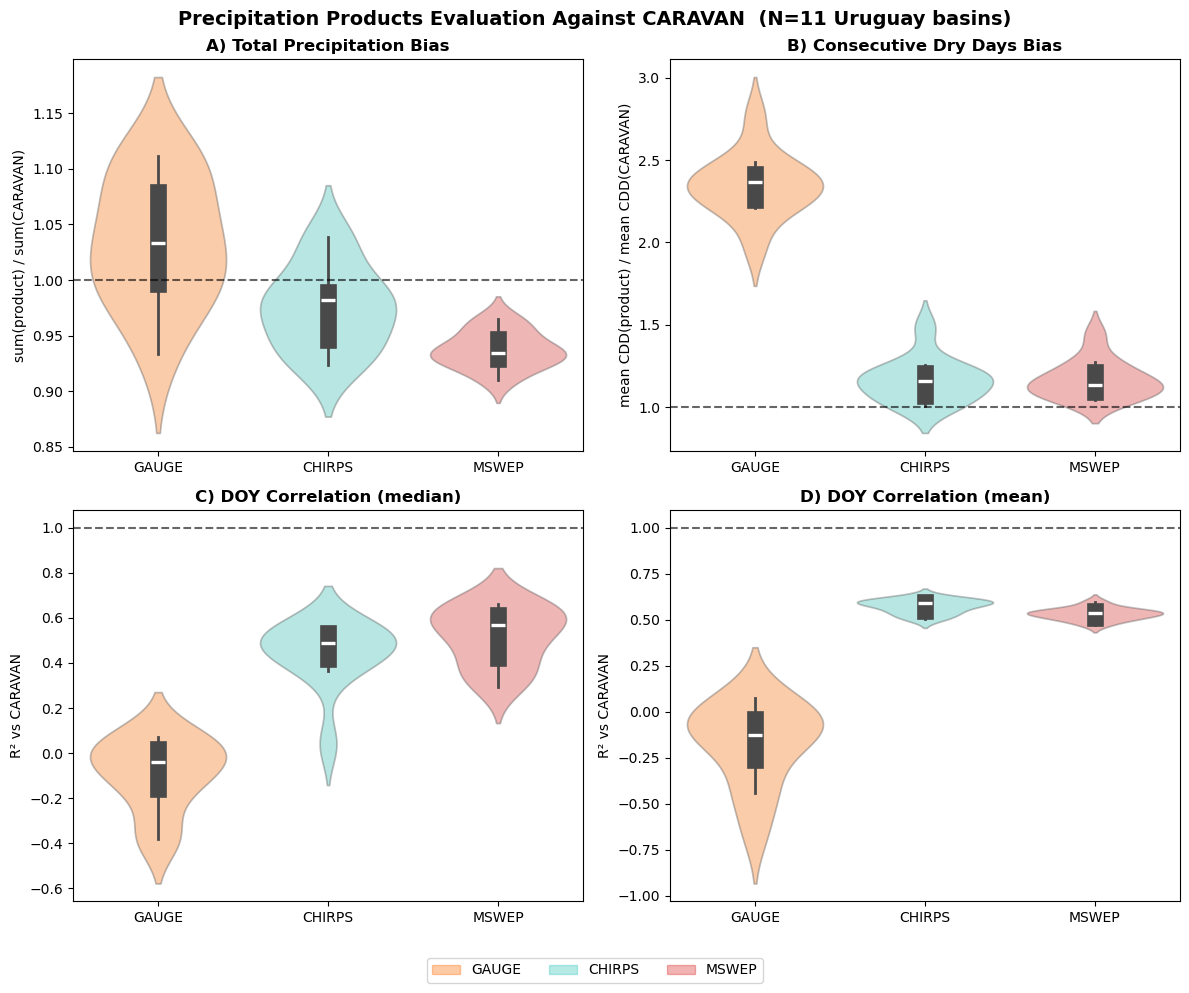

In [19]:
# ── Configuration ──────────────────────────────────────────────────────────────
extended_dataset_dir = Path("../data/time_series")
START_DATE = "1989-10-01"
END_DATE   = "2008-09-30"
PRODUCTS = ["GAUGE", "CHIRPS", "MSWEP"]
VAR_MAP  = {
    "CARAVAN": "prcp_mm_day",
    "GAUGE":   "prcp_gauge_mm_day",
    "CHIRPS":  "prcp_chirps_mm_day",
    "MSWEP":   "prcp_mswep_mm_day",
}
PALETTE = {
    "GAUGE": "#FF6B00", #"#3A86FF",
    "CHIRPS": "#2EC4B6",
    "MSWEP":  "#DC2626",
}

# ── Metric helpers ─────────────────────────────────────────────────────────────
def volume_ratio(arr, ref):
    s = np.nansum(ref)
    return np.nansum(arr) / s if s > 0 else np.nan

def p95_ratio(arr, ref):
    p = np.nanpercentile(ref, 95)
    return np.nanpercentile(arr, 95) / p if p > 0 else np.nan

def mean_dry_spell(arr):
    arr_clean = arr[~np.isnan(arr)]
    mask   = arr_clean == 0
    diff   = np.diff(mask.astype(int))
    starts = np.where(diff ==  1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, len(mask)]
    lengths = (ends - starts)
    lengths = lengths[lengths > 0]
    return np.mean(lengths) if len(lengths) > 0 else np.nan

def dry_spell_ratio(arr, ref):
    m_ref = mean_dry_spell(ref)
    m_arr = mean_dry_spell(arr)
    return m_arr / m_ref if (m_ref and not np.isnan(m_ref) and m_ref > 0) else np.nan

def seasonal_median(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    med = df.groupby("doy")["val"].median()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(med)
    return full.values

def seasonal_corr(arr, ref, dates):
    s_ref = seasonal_median(ref, dates)
    s_arr = seasonal_median(arr, dates)
    if np.std(s_ref) == 0:
        return np.nan
    return r2_score(s_ref, s_arr)

def seasonal_mean(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    mn = df.groupby("doy")["val"].mean()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(mn)
    return full.values

def seasonal_corr_mean(arr, ref, dates):
    s_ref = seasonal_mean(ref, dates)
    s_arr = seasonal_mean(arr, dates)
    if np.std(s_ref) == 0:
        return np.nan
    return r2_score(s_ref, s_arr)

# ── Load basins → build tidy DataFrame ────────────────────────────────────────
records = []
for nc_path in sorted(extended_dataset_dir.glob("*.nc")):
    try:
        ds    = xr.open_dataset(nc_path).sel(date=slice(START_DATE, END_DATE))
        dates = pd.to_datetime(ds["date"].values)
        ref   = ds[VAR_MAP["CARAVAN"]].values.flatten().astype(float)
        if np.nansum(ref) == 0:
            continue
        for prod in PRODUCTS:
            if VAR_MAP[prod] not in ds:
                continue
            arr = ds[VAR_MAP[prod]].values.flatten().astype(float)
            records.append({
                "basin":     nc_path.stem,
                "product":   prod,
                "vol":       volume_ratio(arr, ref),
                # "p95":       p95_ratio(arr, ref),
                "dry":       dry_spell_ratio(arr, ref),
                "seas":      seasonal_corr(arr, ref, dates),
                "seas_mean": seasonal_corr_mean(arr, ref, dates),
            })
    except Exception as e:
        print(f"Skipping {nc_path.name}: {e}")

df = pd.DataFrame(records)
print(f"Processed {df['basin'].nunique()} basins.")

# ── Panel config ───────────────────────────────────────────────────────────────
PANEL_CFG = [
    ("vol",       "A) Total Precipitation Bias",             "sum(product) / sum(CARAVAN)"),
    # ("p95",       "B) P95 Precipitation Bias",        "P95(product) / P95(CARAVAN)"),
    ("dry", "B) Consecutive Dry Days Bias", "mean CDD(product) / mean CDD(CARAVAN)"),
    ("seas",      "C) DOY Correlation (median)", "R² vs CARAVAN"),
    ("seas_mean", "D) DOY Correlation (mean)",   "R² vs CARAVAN"),
]

# ── Plot (2×3 grid, middle bottom slot hidden) ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"Precipitation Products Evaluation Against CARAVAN  (N={df['basin'].nunique()} Uruguay basins)",
             fontsize=14, fontweight="bold")
plot_axes = axes.flatten() 

# axes[1, 2].set_visible(False)

# plot_axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, (col, title, ylabel) in zip(plot_axes, PANEL_CFG):
    sns.violinplot(
        data=df, x="product", y=col,
        hue="product", legend=False,
        palette=PALETTE, order=PRODUCTS,
        inner="box",
        inner_kws={"box_width": 12, "whis_width": 2},
        alpha=0.35, saturation=0.9,
        ax=ax,
    )
    ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

legend_handles = [Patch(color=PALETTE[p], label=p, alpha=0.35) for p in PRODUCTS]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()